# 1 Введение

а. Опишите типы задач, для решения которых полезны рекуррентные нейронные сети.

Языковые модели

б. Приведите 2 примера формулировок задачи в формате «один ко многим», «многие ко многим» и «многие к одному».

Генерация мелодии по жанру, описание товара по id

Машинный перевод, озвучивание текста

Классификация эмоций хорошо/плохо, спам/не спам

в. Представьте, что у вас есть рекуррентная нейронная сеть, которая классифицирует язык входящих слов. Изобразите (в Paint, Drawio и т. д.) с помощью блоков, как эта модель будет обрабатывать слово «Hello». Нарисуйте все входные и выходные данные. Опишите каждый блок с указанием его параметров. Покажите, каким будет начальное значение скрытого состояния.

В теоретической части к заданию. В кратце на вход каждой ячейке сети будет приходить каждый символ слова и выход каждой ячейки будет являться дополнительным входом второго слоя.

г. Объясните основное различие между обычной рекуррентной нейронной сетью, долгой краткосрочной памятью и рекуррентной нейронной сетью с управляемыми рекуррентными ячейками. Нарисуйте LSTM или GRU так же, как RNN.

В теоретической части к заданию.



# 2 Анализ данных

In [ ]:
import pandas as pd
import os
import numpy as np
import random
import warnings
import pickle

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

from sklearn.metrics import silhouette_score

warnings.filterwarnings('ignore')

train_df = pd.read_csv(
    '/content/drive/MyDrive/data/ML10/babynames-clean.csv',
    header=None,
    names=['name', 'gender']
)

print(f"\n Train.csv: {train_df.shape}")
print(train_df.head())


 Train.csv: (6782, 2)
      name gender
0     John    boy
1  William    boy
2    James    boy
3  Charles    boy
4   George    boy


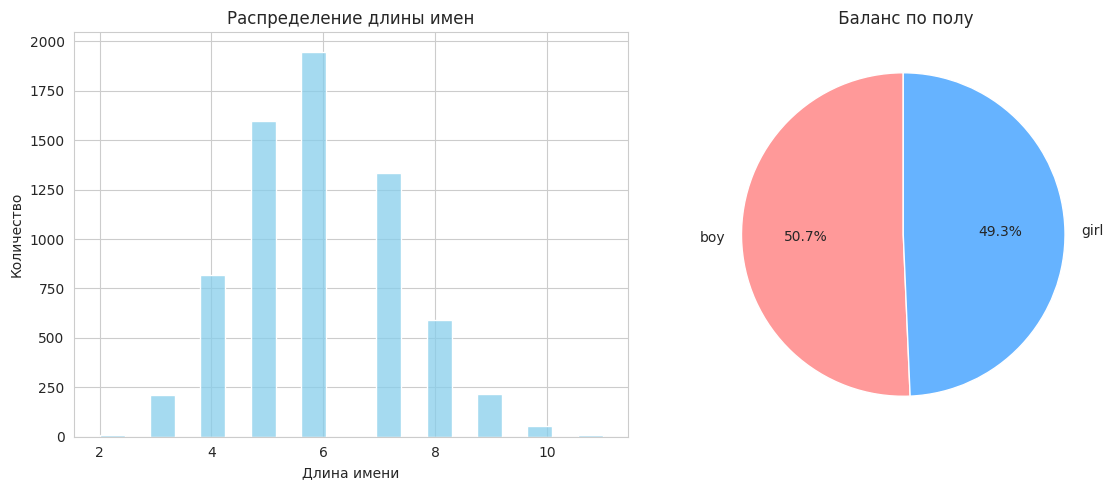

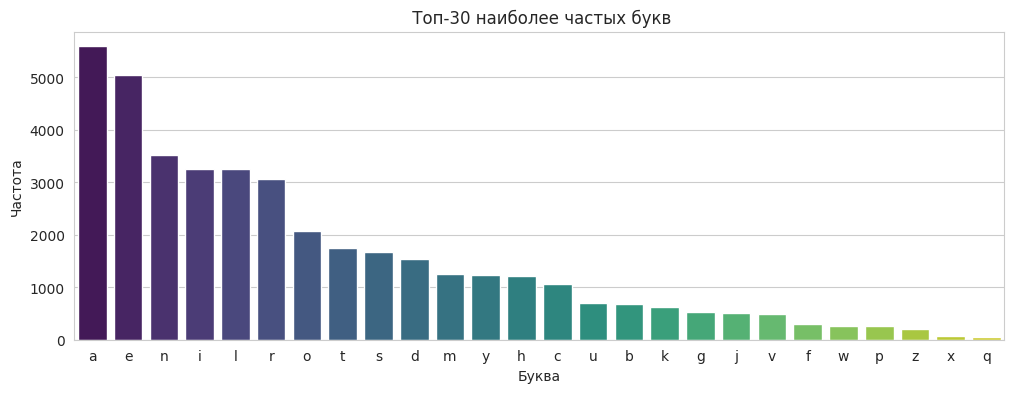

In [ ]:
# Настройка стилей
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

# 2б. Гистограмма длины имен
train_df["name_length"] = train_df["name"].str.len()

plt.subplot(1, 2, 1)
sns.histplot(train_df["name_length"], bins=20, kde=False, color="skyblue")
plt.title("Распределение длины имен")
plt.xlabel("Длина имени")
plt.ylabel("Количество")

# 2в. Баланс по полу
plt.subplot(1, 2, 2)
gender_counts = train_df["gender"].value_counts()
plt.pie(gender_counts, labels=gender_counts.index, autopct="%1.1f%%",
        colors=["#ff9999", "#66b3ff"], startangle=90)
plt.title(" Баланс по полу")

plt.tight_layout()
plt.show()

# 2г. Частота букв
# Собираем все буквы из всех имен (в нижнем регистре)
all_letters = "".join(train_df["name"].str.lower().str.cat())
letter_freq = Counter(all_letters)

# Сортируем по частоте
letter_freq_df = pd.DataFrame(
    letter_freq.items(),
    columns=["letter", "count"]
).sort_values("count", ascending=False)

# График топ букв
plt.figure(figsize=(12, 4))
sns.barplot(x="letter", y="count", data=letter_freq_df.head(30), palette="viridis")
plt.title(" Топ-30 наиболее частых букв")
plt.xlabel("Буква")
plt.ylabel("Частота")
plt.show()


# 3 Подготовка данных

In [ ]:
# 3а, 3б. Кодирование пола и нижний регистр

# Приводим имена к нижнему регистру
train_df['name'] = train_df['name'].str.lower()

# Кодируем пол: boy -> 0, girl -> 1
train_df['gender_encoded'] = (train_df['gender'] == 'girl').astype(int)

print(f" Имена в нижнем регистре. Пол закодирован (0/1).")
print(train_df[['name', 'gender', 'gender_encoded']].head())




 Имена в нижнем регистре. Пол закодирован (0/1).
      name gender  gender_encoded
0     john    boy               0
1  william    boy               0
2    james    boy               0
3  charles    boy               0
4   george    boy               0


In [ ]:
# 3в. Добавление спецтокенов <SOS>, <EOS> и пробелы

SOS_TOKEN = '<SOS>'
EOS_TOKEN = '<EOS>'
PAD_TOKEN = ' '

max_len = train_df['name'].str.len().max()

# Функция для разбиения на токены (буквы как отдельные токены, спецтокены как целые)
def tokenize_name(name):
    """
    Разбивает имя на токены.
    Пример: 'john' -> ['j', 'o', 'h', 'n']
    Но для processed_name: '<SOS>john<EOS>' -> ['<SOS>', 'j', 'o', 'h', 'n', '<EOS>']
    """
    tokens = []
    i = 0
    name_with_tokens = f"{SOS_TOKEN}{name}{EOS_TOKEN}"

    while i < len(name_with_tokens):
        # Проверяем, не начинается ли с SOS_TOKEN
        if name_with_tokens[i:i+len(SOS_TOKEN)] == SOS_TOKEN:
            tokens.append(SOS_TOKEN)
            i += len(SOS_TOKEN)
        # Проверяем, не начинается ли с EOS_TOKEN
        elif name_with_tokens[i:i+len(EOS_TOKEN)] == EOS_TOKEN:
            tokens.append(EOS_TOKEN)
            i += len(EOS_TOKEN)
        else:
            # Обычный символ (буква)
            tokens.append(name_with_tokens[i])
            i += 1

    return tokens

# Создаем колонку с токенами
train_df['tokens'] = train_df['name'].apply(tokenize_name)

# Максимальная длина последовательности (в токенах)
final_max_len = train_df['tokens'].apply(len).max()
print(f" Максимальная длина последовательности (в токенах): {final_max_len}")

print(f"\nПример токенизации:")
print(f"  Исходное имя: '{train_df['name'].iloc[0]}'")
print(f"  Токены: {train_df['tokens'].iloc[0]}")





 Максимальная длина последовательности (в токенах): 13

Пример токенизации:
  Исходное имя: 'john'
  Токены: ['<SOS>', 'j', 'o', 'h', 'n', '<EOS>']


In [ ]:
# 3г. Создание словаря токенов

# Собираем все уникальные токены
all_tokens = set()
for tokens in train_df['tokens']:
    all_tokens.update(tokens)

# Добавляем PAD_TOKEN, если его нет
if PAD_TOKEN not in all_tokens:
    all_tokens.add(PAD_TOKEN)

# Сортируем для воспроизводимости
tokens_list = sorted(list(all_tokens))

# Создаем маппинги: token -> int и int -> token
token_to_idx = {token: idx for idx, token in enumerate(tokens_list)}
idx_to_token = {idx: token for token, idx in token_to_idx.items()}

vocab_size = len(token_to_idx)
print(f"\n Размер словаря: {vocab_size}")
print(f"  Специальные токены:")
print(f"    {SOS_TOKEN} -> {token_to_idx[SOS_TOKEN]}")
print(f"    {EOS_TOKEN} -> {token_to_idx[EOS_TOKEN]}")
print(f"    '{PAD_TOKEN}' -> {token_to_idx[PAD_TOKEN]}")
print(f"\n  Первые 10 токенов: {list(token_to_idx.items())[:10]}")

# 3е. Векторизация имен (Integer Encoding)

def encode_name(tokens, max_length, token_to_idx, pad_token=' '):
    """
    Превращает список токенов в список индексов фиксированной длины.
    """
    # Кодируем токены
    encoded = [token_to_idx[token] for token in tokens]

    # Паддим до max_length
    pad_idx = token_to_idx[pad_token]
    while len(encoded) < max_length:
        encoded.append(pad_idx)

    return encoded

# Применяем ко всему датасету
train_df['encoded_name'] = train_df['tokens'].apply(
    lambda x: encode_name(x, final_max_len, token_to_idx, PAD_TOKEN)
)

# Проверка
print(f"\n Пример кодирования:")
print(f"  Имя: '{train_df['name'].iloc[0]}'")
print(f"  Токены: {train_df['tokens'].iloc[0]}")
print(f"  Вектор индексов: {train_df['encoded_name'].iloc[0]}")
print(f"  Длина вектора: {len(train_df['encoded_name'].iloc[0])}")

# Дополнительная проверка - декодирование обратно
def decode_name(encoded_sequence, idx_to_token, sos_token, eos_token):
    """Декодирует последовательность индексов обратно в имя"""
    tokens = [idx_to_token[idx] for idx in encoded_sequence if idx_to_token[idx] not in [sos_token, eos_token, ' ']]
    return ''.join(tokens)

print(f"\n Проверка декодирования:")
print(f"  Декодированное имя: {decode_name(train_df['encoded_name'].iloc[0], idx_to_token, SOS_TOKEN, EOS_TOKEN)}")

char_to_idx = {token: idx for idx, token in enumerate(tokens_list)}
idx_to_char = {idx: token for token, idx in char_to_idx.items()}


 Размер словаря: 29
  Специальные токены:
    <SOS> -> 2
    <EOS> -> 1
    ' ' -> 0

  Первые 10 токенов: [(' ', 0), ('<EOS>', 1), ('<SOS>', 2), ('a', 3), ('b', 4), ('c', 5), ('d', 6), ('e', 7), ('f', 8), ('g', 9)]

 Пример кодирования:
  Имя: 'john'
  Токены: ['<SOS>', 'j', 'o', 'h', 'n', '<EOS>']
  Вектор индексов: [2, 12, 17, 10, 16, 1, 0, 0, 0, 0, 0, 0, 0]
  Длина вектора: 13

 Проверка декодирования:
  Декодированное имя: john


In [ ]:
# 3f. Разделение на Train / Val / Test (80/10/10)

train_val_df, test_df = train_test_split(
    train_df,
    test_size=0.1,
    random_state=42,
    stratify=train_df['gender_encoded']
)

train_df_final, valid_df = train_test_split(
    train_val_df,
    test_size=0.1111,
    random_state=42,
    stratify=train_val_df['gender_encoded']
)

print(f"   Размеры выборок:")
print(f"   Train: {len(train_df_final)} ({len(train_df_final)/len(train_df)*100:.1f}%)")
print(f"   Valid: {len(valid_df)} ({len(valid_df)/len(train_df)*100:.1f}%)")
print(f"   Test:  {len(test_df)} ({len(test_df)/len(train_df)*100:.1f}%)")

# Сохраняем итоговые датафреймы для удобства
final_train = train_df_final.reset_index(drop=True)
final_valid = valid_df.reset_index(drop=True)
final_test = test_df.reset_index(drop=True)


   Размеры выборок:
   Train: 5424 (80.0%)
   Valid: 679 (10.0%)
   Test:  679 (10.0%)


# 4 Рекуррентная нейронная сеть

In [ ]:
def set_seed(seed=42):

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    print(f" Random seed установлен на {seed}")

set_seed(42)

 Random seed установлен на 42


In [ ]:
# 1. DATASET & COLLATE (Для генерации)
class NameDataset(Dataset):
    def __init__(self, df, char_to_idx, pad_token=' '):
        self.names = df['encoded_name'].tolist()
        self.genders = df['gender_encoded'].tolist()
        self.pad_idx = char_to_idx[pad_token]

    def __len__(self): return len(self.names)

    def __getitem__(self, idx):
        return torch.tensor(self.names[idx]), torch.tensor(self.genders[idx])

def collate_fn(batch):
    names, genders = zip(*batch)
    names = list(names)
    max_len = max(len(n) for n in names)

    # Input: вся последовательность кроме последнего символа
    # Target: вся последовательность со сдвигом на 1 (следующий символ)
    inputs = torch.full((len(names), max_len - 1), 0, dtype=torch.long)
    targets = torch.full((len(names), max_len - 1), 0, dtype=torch.long)

    for i, name in enumerate(names):
        seq = name.tolist() if isinstance(name, torch.Tensor) else name
        # Input: [0..T-2], Target: [1..T-1]
        inputs[i, :len(seq)-1] = torch.tensor(seq[:-1])
        targets[i, :len(seq)-1] = torch.tensor(seq[1:])

    return inputs, targets, torch.tensor(genders)

In [ ]:
# Создаем лоадеры
train_ds = NameDataset(final_train, char_to_idx)
val_ds = NameDataset(final_valid, char_to_idx)
test_ds = NameDataset(final_test, char_to_idx)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_ds, batch_size=64, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False, collate_fn=collate_fn)

sample_batch = next(iter(train_loader))

print(f"Пример входной последовательности (первое имя):")
print(f"Индексы: {sample_batch[0][0][:15]}")
print(f"Токены: {[idx_to_token[idx.item()] for idx in sample_batch[0][0][:15]]}")

Пример входной последовательности (первое имя):
Индексы: tensor([ 2,  6, 17, 22, 22, 11,  7,  1,  0,  0,  0,  0])
Токены: ['<SOS>', 'd', 'o', 't', 't', 'i', 'e', '<EOS>', ' ', ' ', ' ', ' ']


In [ ]:
class CustomRNNCell(nn.Module):
    """
    Кастомная ячейка RNN (Vanilla RNN)
    h_t = tanh(W_ih * x_t + b_ih + W_hh * h_{t-1} + b_hh)
    """
    def __init__(self, input_size, hidden_size, bias=True):
        super(CustomRNNCell, self).__init__()

        self.input_size = input_size
        self.hidden_size = hidden_size

        # Веса для входа x_t
        self.weight_ih = nn.Parameter(torch.Tensor(hidden_size, input_size))

        # Веса для скрытого состояния h_{t-1}
        self.weight_hh = nn.Parameter(torch.Tensor(hidden_size, hidden_size))

        if bias:
            self.bias_ih = nn.Parameter(torch.Tensor(hidden_size))
            self.bias_hh = nn.Parameter(torch.Tensor(hidden_size))
        else:
            self.register_parameter('bias_ih', None)
            self.register_parameter('bias_hh', None)

        self.reset_parameters()

    def reset_parameters(self):
        # Инициализация весов
        nn.init.xavier_uniform_(self.weight_ih)
        nn.init.xavier_uniform_(self.weight_hh)
        if self.bias_ih is not None:
            nn.init.zeros_(self.bias_ih)
            nn.init.zeros_(self.bias_hh)

    def forward(self, x, h=None):
        """
        x: (batch, input_size)
        h: (batch, hidden_size) - предыдущее скрытое состояние
        returns: новое скрытое состояние (batch, hidden_size)
        """
        if h is None:
            h = torch.zeros(x.size(0), self.hidden_size, device=x.device)

        # RNN формула: h_t = tanh(W_ih * x_t + b_ih + W_hh * h_{t-1} + b_hh)
        gate = torch.mm(x, self.weight_ih.t())
        if self.bias_ih is not None:
            gate = gate + self.bias_ih

        gate = gate + torch.mm(h, self.weight_hh.t())
        if self.bias_hh is not None:
            gate = gate + self.bias_hh

        h_new = torch.tanh(gate)

        return h_new


class CustomRNN(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers=1,
                 batch_first=True, dropout=0.0, bias=True):
        super(CustomRNN, self).__init__()

        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.batch_first = batch_first
        self.dropout = dropout

        # Создаем слои из кастомных ячеек
        self.layers = nn.ModuleList()
        for i in range(num_layers):
            layer_input_size = input_size if i == 0 else hidden_size
            self.layers.append(
                CustomRNNCell(layer_input_size, hidden_size, bias)
            )

        if dropout > 0:
            self.dropout_layer = nn.Dropout(dropout)

    def forward(self, x, hidden=None):
        if self.batch_first:
            x = x.transpose(0, 1)

        seq_len, batch_size, _ = x.shape

        if hidden is None:
            hidden = [None] * self.num_layers

        outputs = []

        for t in range(seq_len):
            x_t = x[t]

            for layer_idx, rnn_layer in enumerate(self.layers):
                h_t = hidden[layer_idx] if hidden[layer_idx] is not None else None
                h_new = rnn_layer(x_t, h_t)
                hidden[layer_idx] = h_new
                x_t = h_new

                if self.dropout > 0 and layer_idx < self.num_layers - 1:
                    x_t = self.dropout_layer(x_t)

            outputs.append(x_t)

        outputs = torch.stack(outputs)
        if self.batch_first:
            outputs = outputs.transpose(0, 1)

        return outputs, hidden

In [ ]:
class MultiTaskRNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers=1, dropout=0.3, rnn_type='LSTM'):
        super(MultiTaskRNN, self).__init__()

        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.rnn_type = rnn_type

        self.embedding = nn.Embedding(vocab_size, embed_dim)

        # Выбираем тип RNN
        if rnn_type == 'LSTM':
            self.rnn = nn.LSTM(
                input_size=embed_dim,
                hidden_size=hidden_dim,
                num_layers=num_layers,
                batch_first=True,
                dropout=dropout if num_layers > 1 else 0
            )
        elif rnn_type == 'GRU':
            self.rnn = nn.GRU(
                input_size=embed_dim,
                hidden_size=hidden_dim,
                num_layers=num_layers,
                batch_first=True,
                dropout=dropout if num_layers > 1 else 0
            )
        elif rnn_type == 'CUSTOM':
            self.rnn = CustomRNN(
                input_size=embed_dim,
                hidden_size=hidden_dim,
                num_layers=num_layers,
                batch_first=True,
                dropout=dropout
            )
        else:
            self.rnn = nn.RNN(
                input_size=embed_dim,
                hidden_size=hidden_dim,
                num_layers=num_layers,
                batch_first=True,
                dropout=dropout if num_layers > 1 else 0,
                nonlinearity='tanh'
            )

        self.dropout = nn.Dropout(dropout)
        self.fc_generate = nn.Linear(hidden_dim, vocab_size)
        self.fc_gender = nn.Linear(hidden_dim, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x, hidden=None):
        emb = self.embedding(x)
        out, hidden_state = self.rnn(emb, hidden)
        out = self.dropout(out)
        gen_logits = self.fc_generate(out)
        last_hidden = out[:, -1, :]
        gender_logit = self.fc_gender(last_hidden)
        gender_prob = self.sigmoid(gender_logit)
        return gen_logits, gender_prob

    def init_hidden(self, batch_size, device):
        if self.rnn_type == 'LSTM':
            h_0 = torch.zeros(self.num_layers, batch_size, self.hidden_dim).to(device)
            c_0 = torch.zeros(self.num_layers, batch_size, self.hidden_dim).to(device)
            return (h_0, c_0)
        else:  # RNN, GRU, CUSTOM
            return torch.zeros(self.num_layers, batch_size, self.hidden_dim).to(device)



# 4 Обучение своей RNN

Epoch 1: Train Loss 2.5983 | Val Loss 2.3091
Epoch 2: Train Loss 2.2915 | Val Loss 2.2277
Epoch 3: Train Loss 2.2289 | Val Loss 2.1831
Epoch 4: Train Loss 2.1912 | Val Loss 2.1591
Epoch 5: Train Loss 2.1661 | Val Loss 2.1428
Epoch 6: Train Loss 2.1476 | Val Loss 2.1281
Epoch 7: Train Loss 2.1312 | Val Loss 2.1161
Epoch 8: Train Loss 2.1175 | Val Loss 2.1093
Epoch 9: Train Loss 2.0993 | Val Loss 2.0939
Epoch 10: Train Loss 2.0912 | Val Loss 2.0900


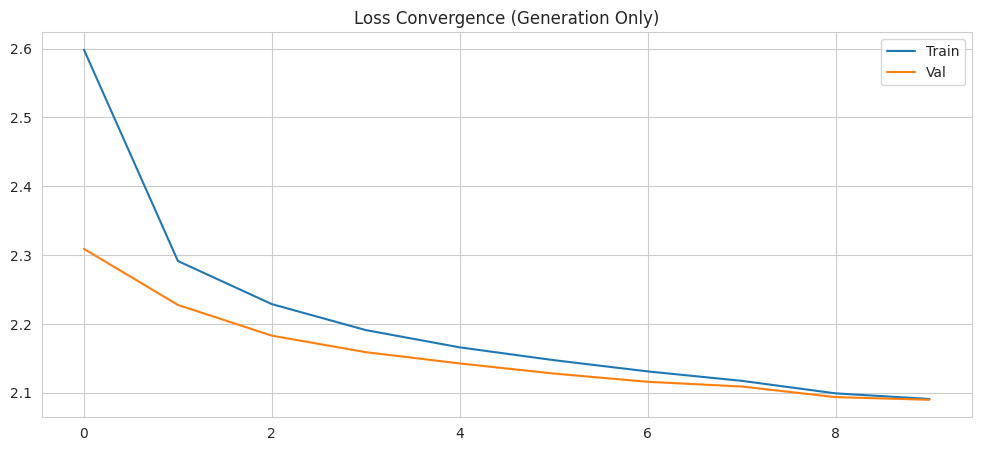

In [ ]:
# 2. ОБУЧЕНИЕ ГЕНЕРАЦИИ

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_cust = MultiTaskRNN(vocab_size=len(char_to_idx), embed_dim=64, hidden_dim=128, rnn_type='CUSTOM').to(device)
optimizer = optim.Adam(model_cust.parameters(), lr=0.001)
criterion_gen = nn.CrossEntropyLoss(ignore_index=char_to_idx[' '])

epochs = 10
history = {'train_loss': [], 'val_loss': []}

for epoch in range(1, epochs + 1):
    model_cust.train()
    total_loss = 0
    for inputs, targets, _ in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        gen_logits, _ = model_cust(inputs)

        # Reshape для CrossEntropy: (N, C, L) -> (N*L, C)
        gen_logits = gen_logits.permute(0, 2, 1)
        loss = criterion_gen(gen_logits, targets)

        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    history['train_loss'].append(total_loss / len(train_loader))

    # Validation
    model_cust.eval()
    val_loss = 0
    with torch.no_grad():
        for inputs, targets, _ in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            gen_logits, _ = model_cust(inputs)
            gen_logits = gen_logits.permute(0, 2, 1)
            val_loss += criterion_gen(gen_logits, targets).item()

    history['val_loss'].append(val_loss / len(val_loader))
    print(f"Epoch {epoch}: Train Loss {history['train_loss'][-1]:.4f} | Val Loss {history['val_loss'][-1]:.4f}")

# График потерь
plt.plot(history['train_loss'], label='Train')
plt.plot(history['val_loss'], label='Val')
plt.title("Loss Convergence (Generation Only)")
plt.legend()
plt.show()

In [ ]:
def generate_name(model, sos_token, eos_token, token_to_idx, idx_to_token, max_length, temperature=1.0, device='cpu'):
    model.eval()

    if sos_token not in token_to_idx:
        raise KeyError(f"Токен '{sos_token}' не найден в словаре!")

    generated_indices = [token_to_idx[sos_token]]
    vocab_size = len(token_to_idx)

    with torch.no_grad():
        for step in range(max_length):
            input_seq = torch.tensor([generated_indices], dtype=torch.long).to(device)
            gen_logits, _ = model(input_seq)

            # Берем логиты для последнего шага
            last_logits = gen_logits[0, -1, :] / temperature

            # Обрезаем логиты до реального размера словаря
            if last_logits.shape[0] > vocab_size:
                last_logits = last_logits[:vocab_size]

            probs = torch.softmax(last_logits, dim=-1)
            next_idx = torch.multinomial(probs, 1).item()

            # Проверяем, что индекс существует
            if next_idx >= vocab_size:
                print(f"Warning: predicted index {next_idx} out of range, using random")
                next_idx = random.randint(0, vocab_size - 1)

            next_token = idx_to_token.get(next_idx)
            if next_token is None:
                print(f"Warning: no token for index {next_idx}, breaking")
                break

            if next_token == eos_token:
                break

            generated_indices.append(next_idx)

    generated_tokens = [idx_to_token[idx] for idx in generated_indices[1:] if idx in idx_to_token]
    generated_name = ''.join(generated_tokens)
    return generated_name

In [ ]:
# Генерируем имена с разной температурой
temperatures = [0.3, 0.5, 1.0, 1.5, 2.0]

for temp in temperatures:
    print(f"\n Температура = {temp}:")
    print("-" * 40)
    for i in range(5):
        name = generate_name(
            model=model_cust,
            sos_token=SOS_TOKEN,
            eos_token=EOS_TOKEN,
            token_to_idx=token_to_idx,
            idx_to_token=idx_to_token,
            max_length=final_max_len,
            temperature=temp,
            device=device
        )
        print(f"  {i+1}. {name}")


 Температура = 0.3:
----------------------------------------
  1. carrey
  2. elie
  3. arista
  4. delin
  5. alissa

 Температура = 0.5:
----------------------------------------
  1. ella
  2. arande
  3. kalyn
  4. jase
  5. rayna

 Температура = 1.0:
----------------------------------------
  1. angel
  2. errica
  3. dwarien
  4. kettmisia
  5. dancell

 Температура = 1.5:
----------------------------------------
  1. empuse
  2. heoptanlemaan
  3. yoissa
  4. denleyna
  5. martalen

 Температура = 2.0:
----------------------------------------
  1. award
  2. rcelte
  3. alpsixno
  4. tanz
  5. ze


In [ ]:
# 4. ОЦЕНКА ПОЛА

model_cust.eval()
all_probs = []
all_labels = []
with torch.no_grad():
    for inputs, _, genders in test_loader:
        inputs = inputs.to(device)
        _, gender_probs = model_cust(inputs)
        all_probs.extend(gender_probs.cpu().numpy())
        all_labels.extend(genders.numpy())

auc_score = roc_auc_score(all_labels, all_probs)
print(f"Test ROC AUC (Gender, untrained head): {auc_score:.4f}")

Test ROC AUC (Gender, untrained head): 0.4314


# 5 GRU

Epoch 1: Train Loss 2.6147 | Val Loss 2.3317
Epoch 2: Train Loss 2.2869 | Val Loss 2.2212
Epoch 3: Train Loss 2.2144 | Val Loss 2.1729
Epoch 4: Train Loss 2.1713 | Val Loss 2.1449
Epoch 5: Train Loss 2.1392 | Val Loss 2.1202
Epoch 6: Train Loss 2.1137 | Val Loss 2.1027
Epoch 7: Train Loss 2.0934 | Val Loss 2.0856
Epoch 8: Train Loss 2.0746 | Val Loss 2.0748
Epoch 9: Train Loss 2.0520 | Val Loss 2.0659
Epoch 10: Train Loss 2.0384 | Val Loss 2.0537


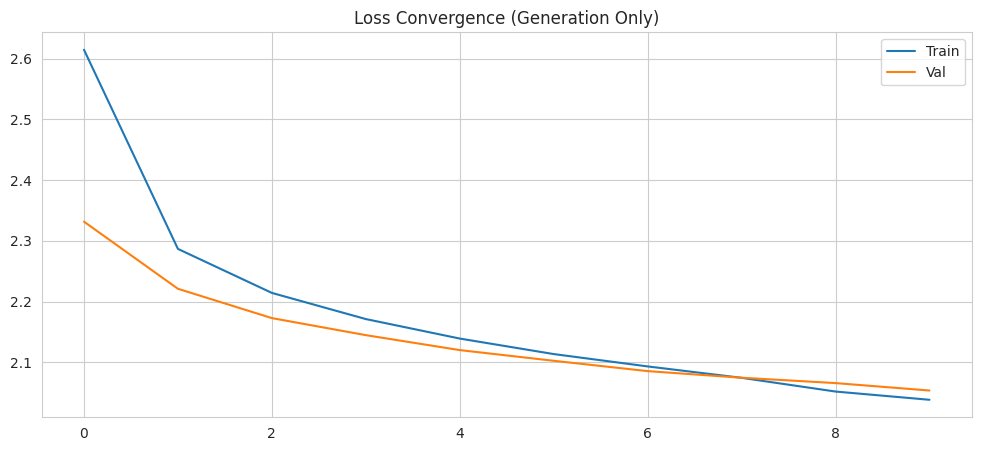

In [ ]:
model_GRU = MultiTaskRNN(vocab_size=len(char_to_idx), embed_dim=64, hidden_dim=128, rnn_type='GRU').to(device)
optimizer = optim.Adam(model_GRU.parameters(), lr=0.001)
criterion_gen = nn.CrossEntropyLoss(ignore_index=char_to_idx[' '])

epochs = 10
history = {'train_loss': [], 'val_loss': []}

for epoch in range(1, epochs + 1):
    model_GRU.train()
    total_loss = 0
    for inputs, targets, _ in train_loader: # Игнорируем пол (_)
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        gen_logits, _ = model_GRU(inputs) # Берем только логины генерации

        # Reshape для CrossEntropy: (N, C, L) -> (N*L, C)
        gen_logits = gen_logits.permute(0, 2, 1)
        loss = criterion_gen(gen_logits, targets)

        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    history['train_loss'].append(total_loss / len(train_loader))

    # Validation
    model_GRU.eval()
    val_loss = 0
    with torch.no_grad():
        for inputs, targets, _ in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            gen_logits, _ = model_GRU(inputs)
            gen_logits = gen_logits.permute(0, 2, 1)
            val_loss += criterion_gen(gen_logits, targets).item()

    history['val_loss'].append(val_loss / len(val_loader))
    print(f"Epoch {epoch}: Train Loss {history['train_loss'][-1]:.4f} | Val Loss {history['val_loss'][-1]:.4f}")

# График потерь
plt.plot(history['train_loss'], label='Train')
plt.plot(history['val_loss'], label='Val')
plt.title("Loss Convergence (Generation Only)")
plt.legend()
plt.show()

In [ ]:
# Генерируем имена с разной температурой
temperatures = [0.5, 1.0, 1.5, 2.0]

for temp in temperatures:
    print(f"\n Температура = {temp}:")
    print("-" * 40)
    for i in range(5):
        name = generate_name(
            model=model_GRU,
            sos_token=SOS_TOKEN,
            eos_token=EOS_TOKEN,
            token_to_idx=token_to_idx,
            idx_to_token=idx_to_token,
            max_length=final_max_len,  # Используем ту же максимальную длину
            temperature=temp,
            device=device
        )
        print(f"  {i+1}. {name}")


 Температура = 0.5:
----------------------------------------
  1. arlen
  2. gord
  3. elina
  4. elver
  5. winna

 Температура = 1.0:
----------------------------------------
  1. jakie
  2. verton
  3. enda
  4. sompy
  5. katilyn

 Температура = 1.5:
----------------------------------------
  1. yalian
  2. markia
  3. nosie
  4. arcara
  5. onzord

 Температура = 2.0:
----------------------------------------
  1. rekaye
  2. ohgy
  3. celona
  4. toqporfog
  5. keorov


In [ ]:
# 4. ОЦЕНКА ПОЛА

model_GRU.eval()
all_probs = []
all_labels = []
with torch.no_grad():
    for inputs, _, genders in test_loader:
        inputs = inputs.to(device)
        _, gender_probs = model_GRU(inputs)
        all_probs.extend(gender_probs.cpu().numpy())
        all_labels.extend(genders.numpy())

auc_score = roc_auc_score(all_labels, all_probs)
print(f"Test ROC AUC (Gender, untrained head): {auc_score:.4f}")

Test ROC AUC (Gender, untrained head): 0.5021


#6 LSTM

Epoch 1: Train Loss 2.6739 | Val Loss 2.3897
Epoch 2: Train Loss 2.3305 | Val Loss 2.2622
Epoch 3: Train Loss 2.2396 | Val Loss 2.2025
Epoch 4: Train Loss 2.1976 | Val Loss 2.1645
Epoch 5: Train Loss 2.1627 | Val Loss 2.1371
Epoch 6: Train Loss 2.1353 | Val Loss 2.1173
Epoch 7: Train Loss 2.1136 | Val Loss 2.1038
Epoch 8: Train Loss 2.0919 | Val Loss 2.0859
Epoch 9: Train Loss 2.0760 | Val Loss 2.0712
Epoch 10: Train Loss 2.0548 | Val Loss 2.0589


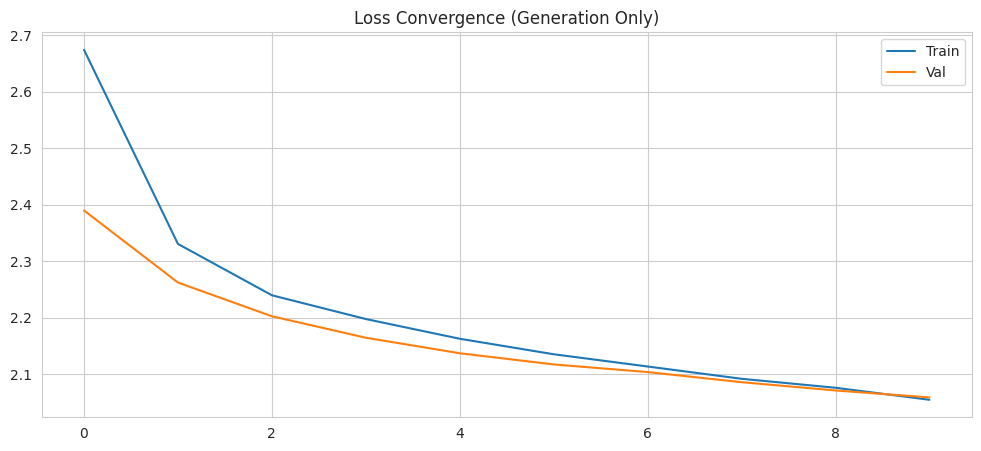

In [ ]:
model_LTSM = MultiTaskRNN(vocab_size=len(char_to_idx), embed_dim=64, hidden_dim=128, rnn_type='LSTM').to(device)
optimizer = optim.Adam(model_LTSM.parameters(), lr=0.001)
criterion_gen = nn.CrossEntropyLoss(ignore_index=char_to_idx[' '])

epochs = 10
history = {'train_loss': [], 'val_loss': []}

for epoch in range(1, epochs + 1):
    model_LTSM.train()
    total_loss = 0
    for inputs, targets, _ in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        gen_logits, _ = model_LTSM(inputs)

        # Reshape для CrossEntropy: (N, C, L) -> (N*L, C)
        gen_logits = gen_logits.permute(0, 2, 1)
        loss = criterion_gen(gen_logits, targets)

        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    history['train_loss'].append(total_loss / len(train_loader))

    # Validation
    model_LTSM.eval()
    val_loss = 0
    with torch.no_grad():
        for inputs, targets, _ in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            gen_logits, _ = model_LTSM(inputs)
            gen_logits = gen_logits.permute(0, 2, 1)
            val_loss += criterion_gen(gen_logits, targets).item()

    history['val_loss'].append(val_loss / len(val_loader))
    print(f"Epoch {epoch}: Train Loss {history['train_loss'][-1]:.4f} | Val Loss {history['val_loss'][-1]:.4f}")

# График потерь
plt.plot(history['train_loss'], label='Train')
plt.plot(history['val_loss'], label='Val')
plt.title("Loss Convergence (Generation Only)")
plt.legend()
plt.show()

In [ ]:
# Генерируем имена с разной температурой
temperatures = [0.5, 1.0, 1.5, 2.0]

for temp in temperatures:
    print(f"\n Температура = {temp}:")
    print("-" * 40)
    for i in range(5):
        name = generate_name(
            model=model_LTSM,
            sos_token=SOS_TOKEN,
            eos_token=EOS_TOKEN,
            token_to_idx=token_to_idx,
            idx_to_token=idx_to_token,
            max_length=final_max_len,  # Используем ту же максимальную длину
            temperature=temp,
            device=device
        )
        print(f"  {i+1}. {name}")


 Температура = 0.5:
----------------------------------------
  1. jene
  2. brande
  3. marky
  4. jayen
  5. jaylen

 Температура = 1.0:
----------------------------------------
  1. chanla
  2. trami
  3. marlea
  4. donique
  5. juline

 Температура = 1.5:
----------------------------------------
  1. iqaya
  2. nrielayn
  3. vtyrsautw
  4. karte
  5. cyn

 Температура = 2.0:
----------------------------------------
  1. plutt
  2. wifynice
  3. ghevinranwah
  4. alo
  5. zodda


In [ ]:
# 4. ОЦЕНКА ПОЛА

model_LTSM.eval()
all_probs = []
all_labels = []
with torch.no_grad():
    for inputs, _, genders in test_loader:
        inputs = inputs.to(device)
        _, gender_probs = model_LTSM(inputs)
        all_probs.extend(gender_probs.cpu().numpy())
        all_labels.extend(genders.numpy())

auc_score = roc_auc_score(all_labels, all_probs)
print(f"Test ROC AUC (Gender, untrained head): {auc_score:.4f}")

Test ROC AUC (Gender, untrained head): 0.5627


#7 Сравнение моделей, Perplexity

In [ ]:
def calculate_perplexity_from_loss(loss_value):
    """
    Рассчитываем perplexity из кросс-энтропийной потери
    """
    return np.exp(loss_value)

def calculate_perplexity_from_logits(logits, targets, pad_idx):
    """
    Рассчитываем perplexity напрямую из логитов модели
    """
    # Преобразуем логиты в вероятности
    probs = F.softmax(logits, dim=-1)

    # Берем вероятности правильных токенов
    batch_size, seq_len, vocab_size = logits.shape
    probs_flat = probs.reshape(-1, vocab_size)
    targets_flat = targets.reshape(-1)

    # Маска для игнорирования PAD токенов
    mask = targets_flat != pad_idx

    # Вероятности правильных предсказаний
    correct_probs = probs_flat[torch.arange(len(targets_flat)), targets_flat]
    correct_probs = correct_probs[mask]

    # Средняя логарифмическая вероятность
    mean_log_prob = torch.mean(torch.log(correct_probs + 1e-10))

    # Perplexity
    perplexity = torch.exp(-mean_log_prob)

    return perplexity.item()

In [ ]:
def random_model_perplexity(vocab_size):
    """
    Случайная модель: равные вероятности для всех букв
    """
    # Для случайной модели вероятность каждой буквы = 1/vocab_size
    prob_correct = 1.0 / vocab_size
    mean_log_prob = np.log(prob_correct)
    perplexity = np.exp(-mean_log_prob)
    return perplexity

# Пример расчета
vocab_size = len(char_to_idx)
random_perp = random_model_perplexity(vocab_size)
print(f"Random model perplexity: {random_perp:.2f}")
print(f"(Должно быть равно vocab_size = {vocab_size})")

Random model perplexity: 29.00
(Должно быть равно vocab_size = 29)


In [ ]:
def letter_frequency_model_perplexity(df, char_to_idx):
    """
    Модель, которая предсказывает буквы на основе их частоты в обучающих данных
    """
    # Собираем частоты букв из всех имен
    all_chars = []
    for name in df['name']:
        all_chars.extend(list(name))

    # Считаем частоты
    from collections import Counter
    char_counts = Counter(all_chars)

    # Нормируем в вероятности
    total = sum(char_counts.values())
    char_probs = {char: count/total for char, count in char_counts.items()}

    # Для токенов, которых нет в обучающих данных, даем маленькую вероятность
    for token in char_to_idx.keys():
        if token not in char_probs:
            char_probs[token] = 1e-6

    # Нормируем заново
    total = sum(char_probs.values())
    char_probs = {char: prob/total for char, prob in char_probs.items()}

    # Perplexity для этой модели
    # Чем выше вероятность популярных букв, тем меньше perplexity
    mean_log_prob = np.mean([np.log(prob) for prob in char_probs.values()])
    perplexity = np.exp(-mean_log_prob)

    return perplexity, char_probs

# Расчет
freq_perp, char_probs = letter_frequency_model_perplexity(final_train, char_to_idx)
print(f"Letter frequency model perplexity: {freq_perp:.2f}")

# Показываем топ-10 самых популярных букв
print("\nТоп-10 самых популярных букв:")
sorted_probs = sorted(char_probs.items(), key=lambda x: x[1], reverse=True)[:10]
for char, prob in sorted_probs:
    print(f"  '{char}': {prob:.4f}")

Letter frequency model perplexity: 128.06

Топ-10 самых популярных букв:
  'a': 0.1378
  'e': 0.1258
  'n': 0.0883
  'i': 0.0805
  'l': 0.0805
  'r': 0.0761
  'o': 0.0520
  't': 0.0435
  's': 0.0416
  'd': 0.0381


In [ ]:
def evaluate_model_5runs(model, test_loader, char_to_idx, device, n_runs=5, base_seed=42):
    """
    Оценивает perplexity модели n_runs раз с разными seed'ами.
    Возвращает список из n_runs значений perplexity.
    """
    perplexities = []
    pad_idx = char_to_idx[' ']
    for run in range(n_runs):

        model.eval()

        all_logits = []
        all_targets = []

        with torch.no_grad():
            for inputs, targets, _ in test_loader:
                inputs, targets = inputs.to(device), targets.to(device)
                gen_logits, _ = model(inputs)
                all_logits.append(gen_logits.cpu())
                all_targets.append(targets.cpu())

        logits_batch = torch.cat(all_logits, dim=0)
        targets_batch = torch.cat(all_targets, dim=0)

        # Используем ВАШУ функцию
        perp = calculate_perplexity_from_logits(logits_batch, targets_batch, pad_idx)
        perplexities.append(perp)

    return perplexities

perps_cust = evaluate_model_5runs(model_cust, test_loader, char_to_idx, device, n_runs=5, base_seed=42)
print(f"Custom RNN: mean={np.mean(perps_cust):.2f}")

perps_lstm = evaluate_model_5runs(model_LTSM, test_loader, char_to_idx, device, n_runs=5, base_seed=42)
print(f"LSTM: mean={np.mean(perps_lstm):.2f}")

perps_gru = evaluate_model_5runs(model_GRU, test_loader, char_to_idx, device, n_runs=5, base_seed=42)
print(f"GRU:  mean={np.mean(perps_gru):.2f}")

# === Базовые модели (ваши функции, без дисперсии) ===
vocab_size = len(char_to_idx)
random_perp = random_model_perplexity(vocab_size)
freq_perp, _ = letter_frequency_model_perplexity(final_train, char_to_idx)
print(f"\n Базовые модели:")
print(f"Random:           {random_perp:.2f}")
print(f"Letter Frequency: {freq_perp:.2f}")

Custom RNN: mean=8.00
LSTM: mean=7.72
GRU:  mean=7.57

 Базовые модели:
Random:           29.00
Letter Frequency: 128.06


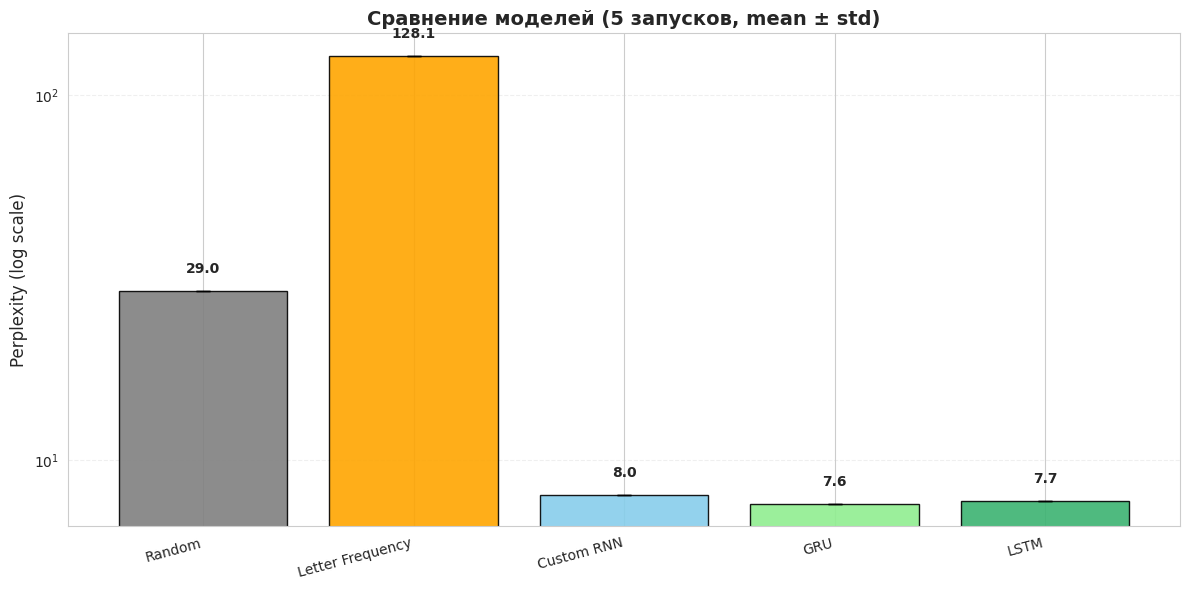

In [ ]:
models = ['Random', 'Letter Frequency', 'Custom RNN', 'GRU', 'LSTM']
means = [
    random_perp,
    freq_perp,
    np.mean(perps_cust),
    np.mean(perps_gru),
    np.mean(perps_lstm)
]
stds = [
    0,  # Random
    0,  # Frequency
    np.std(perps_cust, ddof=1),
    np.std(perps_gru, ddof=1),
    np.std(perps_lstm, ddof=1)
]
colors = ['gray', 'orange', 'skyblue', 'lightgreen', 'mediumseagreen']

plt.figure(figsize=(12, 6))

# Error bars: 0 для базовых моделей, std для обученных
yerr = [std if std > 0 else 0 for std in stds]

bars = plt.bar(models, means, yerr=yerr, capsize=5,
               color=colors, edgecolor='black', alpha=0.9)

plt.yscale('log')
plt.ylabel('Perplexity (log scale)', fontsize=12)
plt.title('Сравнение моделей (5 запусков, mean ± std)', fontsize=14, fontweight='bold')

# Подписи значений на столбцах
for bar, mean, std in zip(bars, means, stds):
    height = bar.get_height()
    label = f'{mean:.1f}' if std == 0 else f'{mean:.1f}±{std:.1f}'
    plt.text(bar.get_x() + bar.get_width()/2, height * 1.1,
            label, ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.grid(True, alpha=0.3, axis='y', linestyle='--')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()


# 8 Классификация по полу

In [ ]:

# model_LTSM = MultiTaskRNN(vocab_size=len(char_to_idx), embed_dim=64, hidden_dim=128, rnn_type='LSTM').to(device)
# optimizer = optim.Adam(model_LTSM.parameters(), lr=0.001)

epochs = 10
criterion_gender = nn.BCELoss()

# Добавляем списки для хранения истории потерь
train_losses_bce = []
val_losses_bce = []

for epoch in range(epochs):
    # Обучение
    model_LTSM.train()
    total_train_loss = 0

    for inputs, gen_targets, gender_targets in train_loader:
        inputs = inputs.to(device)
        gen_targets = gen_targets.to(device)
        gender_targets = gender_targets.to(device).float()

        optimizer.zero_grad()
        gen_logits, gender_probs = model_LTSM(inputs)
        gender_probs = gender_probs.squeeze()
        loss_gender = criterion_gender(gender_probs, gender_targets)
        loss_gender.backward()
        optimizer.step()

        total_train_loss += loss_gender.item()

    avg_train_loss = total_train_loss / len(train_loader)
    train_losses_bce.append(avg_train_loss)

    # Валидация
    model_LTSM.eval()
    total_val_loss = 0

    with torch.no_grad():
        for inputs, _, gender_targets in val_loader:
            inputs = inputs.to(device)
            gender_targets = gender_targets.to(device).float()
            _, gender_probs = model_LTSM(inputs)
            gender_probs = gender_probs.squeeze()
            loss = criterion_gender(gender_probs, gender_targets)
            total_val_loss += loss.item()

    avg_val_loss = total_val_loss / len(val_loader)
    val_losses_bce.append(avg_val_loss)

    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

Epoch 1/10 | Train Loss: 0.5443 | Val Loss: 0.4481
Epoch 2/10 | Train Loss: 0.4148 | Val Loss: 0.4133
Epoch 3/10 | Train Loss: 0.3678 | Val Loss: 0.4004
Epoch 4/10 | Train Loss: 0.3422 | Val Loss: 0.4104
Epoch 5/10 | Train Loss: 0.3125 | Val Loss: 0.3733
Epoch 6/10 | Train Loss: 0.2887 | Val Loss: 0.4602
Epoch 7/10 | Train Loss: 0.2735 | Val Loss: 0.4282
Epoch 8/10 | Train Loss: 0.2456 | Val Loss: 0.4268
Epoch 9/10 | Train Loss: 0.2186 | Val Loss: 0.4200
Epoch 10/10 | Train Loss: 0.2008 | Val Loss: 0.4406


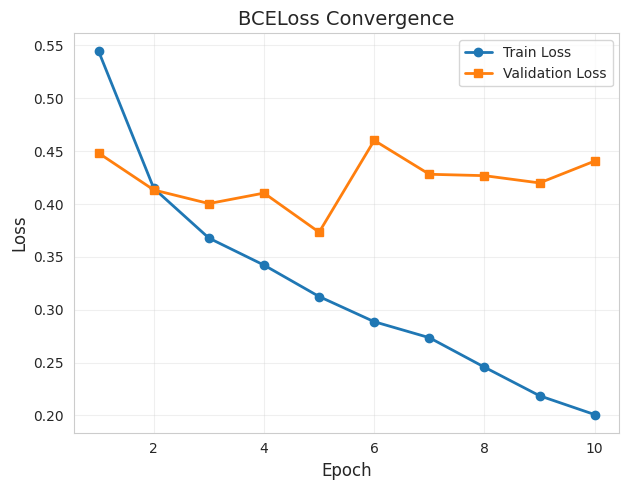


Финальные потери (BCELoss) - Train: 0.2008, Val: 0.4406


In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, epochs+1), train_losses_bce, label='Train Loss', marker='o', linewidth=2)
plt.plot(range(1, epochs+1), val_losses_bce, label='Validation Loss', marker='s', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('BCELoss Convergence', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nФинальные потери (BCELoss) - Train: {train_losses_bce[-1]:.4f}, Val: {val_losses_bce[-1]:.4f}")


In [ ]:
model_LTSM.eval()
for i in range(10):
    name = generate_name(
        model=model_LTSM,
        sos_token=SOS_TOKEN,
        eos_token=EOS_TOKEN,
        token_to_idx=token_to_idx,
        idx_to_token=idx_to_token,
        max_length=final_max_len,
        temperature=1.0,
        device=device
    )
    print(f"{i+1}. {name}")

1. mergrust
2. gyvebrioska
3. gakrenet
4. aliah
5. kirri
6. clingorth
7. meldonel
8. donmjulyns
9. busty<SOS>
10. panda


In [ ]:
model_LTSM.eval()
all_probs = []
all_labels = []
with torch.no_grad():
    for inputs, _, genders in test_loader:
        inputs = inputs.to(device)
        _, gender_probs = model_LTSM(inputs)
        all_probs.extend(gender_probs.cpu().numpy())
        all_labels.extend(genders.numpy())

auc_score = roc_auc_score(all_labels, all_probs)
print(f" Test ROC AUC (Gender, untrained head): {auc_score:.4f}")

 Test ROC AUC (Gender, untrained head): 0.9024


In [ ]:
model = MultiTaskRNN(vocab_size=len(char_to_idx), embed_dim=64, hidden_dim=128, rnn_type='LSTM').to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)

criterion_nll = nn.NLLLoss()

train_losses_nll = []
val_losses_nll = []

for epoch in range(epochs):
    # Обучение
    model.train()
    total_train_loss = 0

    for inputs, gen_targets, gender_targets in train_loader:
        inputs = inputs.to(device)
        gender_targets = gender_targets.to(device).long()

        optimizer.zero_grad()
        gen_logits, gender_probs = model(inputs)
        gender_two_classes = torch.stack([1 - gender_probs, gender_probs], dim=1).squeeze(2)
        gender_log_probs = torch.log(gender_two_classes + 1e-8)
        loss = criterion_nll(gender_log_probs, gender_targets)
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader)
    train_losses_nll.append(avg_train_loss)

    # Валидация
    model.eval()
    total_val_loss = 0

    with torch.no_grad():
        for inputs, _, gender_targets in val_loader:
            inputs = inputs.to(device)
            gender_targets = gender_targets.to(device).long()
            _, gender_probs = model(inputs)
            gender_two_classes = torch.stack([1 - gender_probs, gender_probs], dim=1).squeeze(2)
            gender_log_probs = torch.log(gender_two_classes + 1e-8)
            loss = criterion_nll(gender_log_probs, gender_targets)
            total_val_loss += loss.item()

    avg_val_loss = total_val_loss / len(val_loader)
    val_losses_nll.append(avg_val_loss)

    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")



Epoch 1/10 | Train Loss: 0.5819 | Val Loss: 0.4728
Epoch 2/10 | Train Loss: 0.4505 | Val Loss: 0.4368
Epoch 3/10 | Train Loss: 0.4192 | Val Loss: 0.4188
Epoch 4/10 | Train Loss: 0.4036 | Val Loss: 0.4121
Epoch 5/10 | Train Loss: 0.3842 | Val Loss: 0.4123
Epoch 6/10 | Train Loss: 0.3634 | Val Loss: 0.3982
Epoch 7/10 | Train Loss: 0.3429 | Val Loss: 0.3939
Epoch 8/10 | Train Loss: 0.3314 | Val Loss: 0.4097
Epoch 9/10 | Train Loss: 0.3137 | Val Loss: 0.3940
Epoch 10/10 | Train Loss: 0.3016 | Val Loss: 0.4026


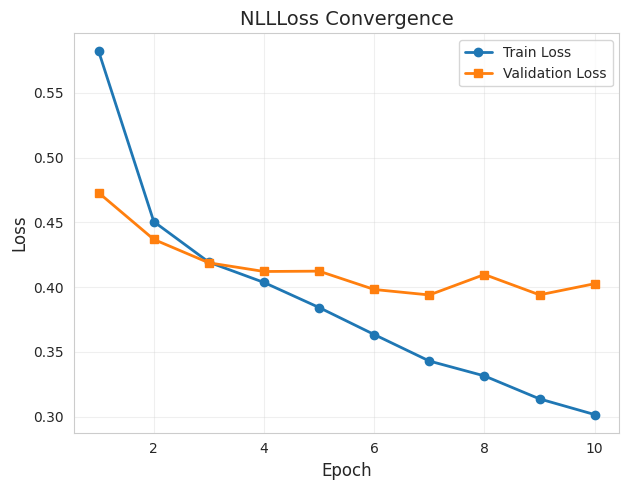

Финальные потери (NLLLoss) - Train: 0.3016, Val: 0.4026


In [ ]:
# График для NLLLoss
plt.subplot(1, 2, 2)
plt.plot(range(1, epochs+1), train_losses_nll, label='Train Loss', marker='o', linewidth=2)
plt.plot(range(1, epochs+1), val_losses_nll, label='Validation Loss', marker='s', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('NLLLoss Convergence', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Финальные потери (NLLLoss) - Train: {train_losses_nll[-1]:.4f}, Val: {val_losses_nll[-1]:.4f}")

In [ ]:
model.eval()
all_probs = []
all_labels = []
with torch.no_grad():
    for inputs, _, genders in test_loader:
        inputs = inputs.to(device)
        _, gender_probs = model(inputs)
        all_probs.extend(gender_probs.cpu().numpy())
        all_labels.extend(genders.numpy())

auc_score = roc_auc_score(all_labels, all_probs)
print(f" Test ROC AUC (Gender, untrained head): {auc_score:.4f}")

 Test ROC AUC (Gender, untrained head): 0.9099


#9 Исчезающий градиент

In [ ]:
# 1. Находим модальную реальную длину (без PAD)
real_lengths = [len(tokens) for tokens in final_train['tokens']]
modal_len = Counter(real_lengths).most_common(1)[0][0]
print(f" Модальная длина имён: {modal_len}")

# 2. Фильтруем датасет
modal_indices = [i for i, tokens in enumerate(final_train['tokens']) if len(tokens) == modal_len]
modal_ds = Subset(train_ds, modal_indices)

# 3. DataLoader с batch_size=1 (сохраняем полную длину, чтобы хук видел все токены)
def modal_collate(batch):
    inputs, genders = zip(*batch)
    inputs = torch.stack([x.squeeze(0) for x in inputs]) # (1, seq_len)
    genders = torch.tensor(genders)
    return inputs, genders

modal_loader = DataLoader(modal_ds, batch_size=1, shuffle=False, collate_fn=modal_collate)

 Модальная длина имён: 8


In [ ]:
class GradCollector:
    def __init__(self): self.gradients = []
    def hook_fn(self, module, grad_input, grad_output):
        # grad_output[0] имеет форму (batch, seq_len, embed_dim)
        self.gradients.append(grad_output[0].detach().cpu())
    def reset(self): self.gradients = []

collector = GradCollector()

def train_and_collect(rnn_type, n_epochs, task='gender'):
    """Инициализирует модель, обучает, собирает градиенты эмбеддинга"""
    model = MultiTaskRNN(vocab_size=len(char_to_idx), embed_dim=64,
                         hidden_dim=128, rnn_type=rnn_type).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = torch.nn.BCELoss() if task == 'gender' else torch.nn.CrossEntropyLoss(ignore_index=char_to_idx[' '])

    hook_handle = model.embedding.register_full_backward_hook(collector.hook_fn)
    model.train()
    history = [] # Будет содержать тензоры (seq_len, embed_dim)

    for epoch in range(n_epochs):
        collector.reset()
        for inputs, genders in modal_loader:
            inputs = inputs.to(device)
            optimizer.zero_grad()

            if task == 'gender':
                genders = genders.to(device).float()
                _, gender_probs = model(inputs)
                loss = criterion(gender_probs.squeeze(), genders.squeeze())
            else:  # generation (teacher forcing)
                gen_in = inputs[:, :-1]
                gen_target = inputs[:, 1:]
                gen_logits, _ = model(gen_in)
                loss = criterion(gen_logits.permute(0, 2, 1), gen_target)

            loss.backward()  # Хук срабатывает здесь
            optimizer.step()

        # Усредняем градиенты по батчам за эпоху
        if collector.gradients:
            epoch_grads = torch.stack(collector.gradients).mean(dim=0).squeeze(0)
            history.append(epoch_grads)

    hook_handle.remove()
    return torch.stack(history).unsqueeze(2)

print("\n Отладка: 1 эпоха, сбор градиентов...")
debug_grads = train_and_collect('LSTM', n_epochs=1, task='gender')
debug_grads = debug_grads.squeeze(2)

grad_norms = torch.norm(debug_grads, dim=2)  # (1, seq_len)
print(f"Форма тензора норм: {grad_norms.shape}")

with torch.no_grad():
    sample_input, _ = next(iter(modal_loader))
    sample_tokens = sample_input[0].cpu().numpy()
    nz_positions = np.where(grad_norms[0].numpy() > 1e-7)[0]
    print(f"Входные токены: {sample_tokens}")
    print(f"Позиции с ненулевым градиентом (обратный порядок!): {nz_positions[::-1]}")

avg_norm_per_pos = torch.norm(debug_grads, dim=2).mean(dim=0).cpu().numpy()
print(f"Средняя норма по позициям: {avg_norm_per_pos}")


 Отладка: 1 эпоха, сбор градиентов...
Форма тензора норм: torch.Size([1, 13])
Входные токены: [ 2  3 15 18  3 20 17  1  0  0  0  0  0]
Позиции с ненулевым градиентом (обратный порядок!): [12 11 10  9  8  7  6  5  4  3  2  1  0]
Средняя норма по позициям: [7.5363867e-05 1.5993284e-04 2.9026819e-04 3.2113810e-04 5.5140990e-04
 1.6438809e-03 2.9754108e-03 9.2510047e-04 1.8083042e-04 1.4237333e-04
 1.9441619e-04 2.8676115e-04 9.0939994e-04]



 Сравнение для классификации пола:

 Обучение RNN | Задача: gender
 Реальная длина последовательности (с паддингом): 13

 Обучение GRU | Задача: gender

 Обучение LSTM | Задача: gender


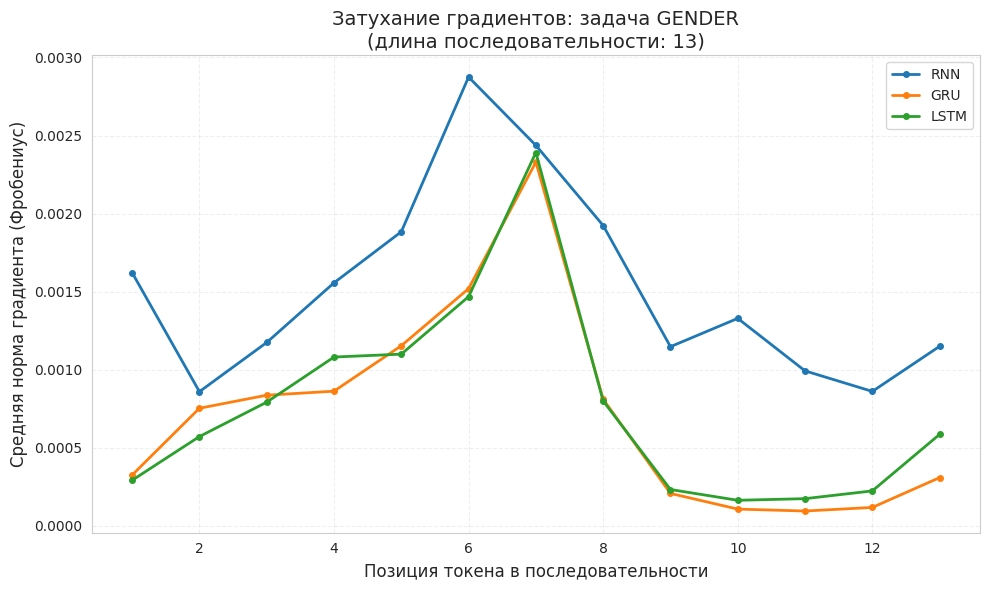


 Сравнение для генерации букв:

 Обучение RNN | Задача: gen
 Реальная длина последовательности (с паддингом): 12

 Обучение GRU | Задача: gen

 Обучение LSTM | Задача: gen


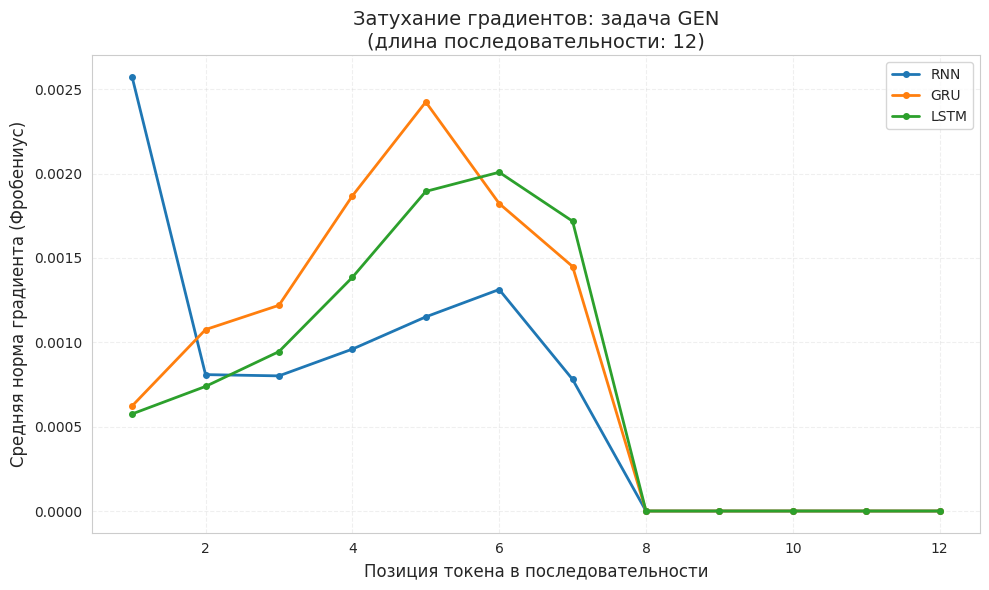

In [ ]:
import matplotlib.pyplot as plt

def compare_architectures(task, n_epochs=5):
    results = {}
    seq_len = None

    for rtype in ['RNN', 'GRU', 'LSTM']:
        print(f"\n Обучение {rtype} | Задача: {task}")
        grads = train_and_collect(rtype, n_epochs, task)  # (n_epochs, seq_len, 1, embed_dim)
        grads = grads.squeeze(2)  # -> (n_epochs, seq_len, embed_dim)

        # Запоминаем длину последовательности из первого же запуска
        if seq_len is None:
            seq_len = grads.shape[1]
            print(f" Реальная длина последовательности (с паддингом): {seq_len}")

        # Норма Фробениуса по embed_dim -> среднее по эпохам
        norms = torch.norm(grads, dim=2).mean(dim=0).cpu().numpy()  # (seq_len,)
        results[rtype] = norms

    # Построение графика: используем seq_len из данных, а не modal_len
    plt.figure(figsize=(10, 6))
    positions = range(1, seq_len + 1)

    for name, norms in results.items():
        plt.plot(positions, norms, label=name, marker='o', linewidth=2, markersize=4)

    plt.xlabel('Позиция токена в последовательности', fontsize=12)
    plt.ylabel('Средняя норма градиента (Фробениус)', fontsize=12)
    plt.title(f'Затухание градиентов: задача {task.upper()}\n(длина последовательности: {seq_len})', fontsize=14)
    plt.legend()
    plt.grid(True, alpha=0.3, linestyle='--')
    plt.tight_layout()
    plt.show()

    return results

print("\n Сравнение для классификации пола:")
gender_results = compare_architectures('gender', n_epochs=5)

print("\n Сравнение для генерации букв:")
gen_results = compare_architectures('gen', n_epochs=5)

g. В чём разница между задачами?

При генерации букв используется Backpropagation Through Time (BPTT): градиенты проходят через рекуррентные ячейки на каждом шаге последовательности, многократно умножаясь на матрицы весов. Это усиливает затухание/взрыв градиентов, особенно в начале имени. При классификации пола ошибка вычисляется один раз по последнему скрытому состоянию, поэтому градиентный поток короче и стабильнее.

h. Почему имена фиксированной длины?

Необходимо подавать в модель фиксированную длину


# 10 Многозадачное обучение

In [ ]:
# 1. Инициализация новой модели
model_mtl = MultiTaskRNN(vocab_size=len(char_to_idx), embed_dim=64,
                         hidden_dim=128, rnn_type='LSTM').to(device)

optimizer = optim.Adam(model_mtl.parameters(), lr=0.001)

# 2. Критерии потерь
criterion_gen = nn.CrossEntropyLoss(ignore_index=char_to_idx[' '])
criterion_gender = nn.BCELoss()

epochs = 10

# Списки для хранения истории (Task b.i)
history_mtl = {
    'train_gen_loss': [], 'val_gen_loss': [],
    'train_gender_loss': [], 'val_gender_loss': []
}

print(" Запуск многозадачного обучения (Multi-Task Learning)...")

for epoch in range(epochs):
    model_mtl.train()
    epoch_train_gen, epoch_train_gender = 0, 0

    for inputs, targets, genders in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        genders = genders.to(device).float()

        optimizer.zero_grad()

        # Forward pass (возвращает оба выхода)
        gen_logits, gender_probs = model_mtl(inputs)

        # Потеря генерации (нужно permute для CrossEntropy)
        loss_gen = criterion_gen(gen_logits.permute(0, 2, 1), targets)

        # Потеря классификации (нужно squeeze и float)
        loss_gender = criterion_gender(gender_probs.squeeze(-1), genders)

        # Суммарная потеря (можно добавить веса)
        total_loss = loss_gen + loss_gender

        total_loss.backward()
        optimizer.step()

        epoch_train_gen += loss_gen.item()
        epoch_train_gender += loss_gender.item()

    history_mtl['train_gen_loss'].append(epoch_train_gen / len(train_loader))
    history_mtl['train_gender_loss'].append(epoch_train_gender / len(train_loader))

    # --- VALIDATION ---
    model_mtl.eval()
    epoch_val_gen, epoch_val_gender = 0, 0

    with torch.no_grad():
        for inputs, targets, genders in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            genders = genders.to(device).float()

            gen_logits, gender_probs = model_mtl(inputs)

            loss_gen = criterion_gen(gen_logits.permute(0, 2, 1), targets)
            loss_gender = criterion_gender(gender_probs.squeeze(-1), genders)

            epoch_val_gen += loss_gen.item()
            epoch_val_gender += loss_gender.item()

    history_mtl['val_gen_loss'].append(epoch_val_gen / len(val_loader))
    history_mtl['val_gender_loss'].append(epoch_val_gender / len(val_loader))

    print(f"Epoch {epoch+1}/{epochs} | Gen Loss: {history_mtl['val_gen_loss'][-1]:.4f} | Gender Loss: {history_mtl['val_gender_loss'][-1]:.4f}")

 Запуск многозадачного обучения (Multi-Task Learning)...
Epoch 1/10 | Gen Loss: 2.4348 | Gender Loss: 0.4994
Epoch 2/10 | Gen Loss: 2.3108 | Gender Loss: 0.4593
Epoch 3/10 | Gen Loss: 2.2529 | Gender Loss: 0.4251
Epoch 4/10 | Gen Loss: 2.2170 | Gender Loss: 0.4408
Epoch 5/10 | Gen Loss: 2.1908 | Gender Loss: 0.4198
Epoch 6/10 | Gen Loss: 2.1697 | Gender Loss: 0.4395
Epoch 7/10 | Gen Loss: 2.1516 | Gender Loss: 0.3944
Epoch 8/10 | Gen Loss: 2.1351 | Gender Loss: 0.3969
Epoch 9/10 | Gen Loss: 2.1243 | Gender Loss: 0.4299
Epoch 10/10 | Gen Loss: 2.1162 | Gender Loss: 0.3909


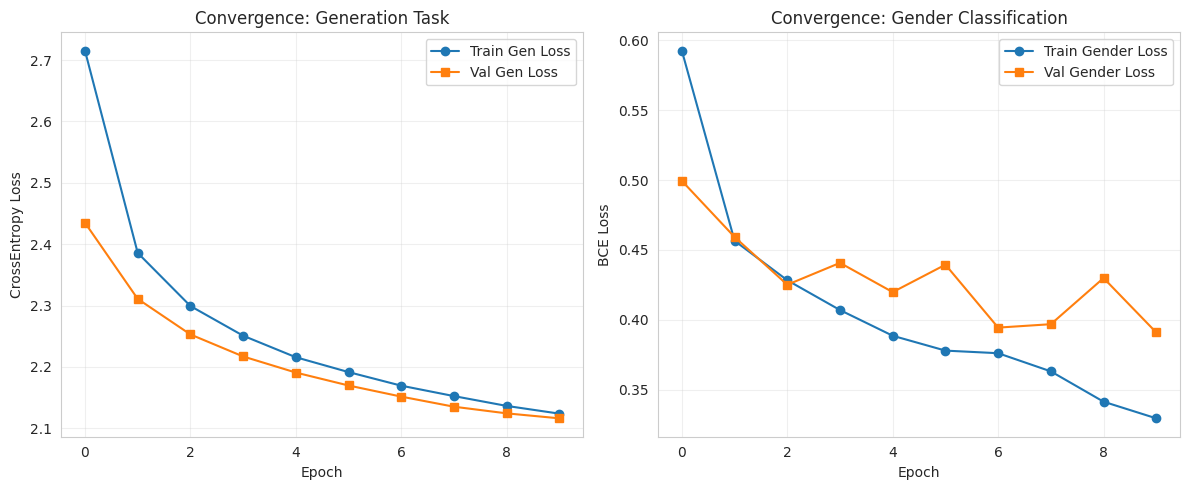

In [ ]:
plt.figure(figsize=(12, 5))

# График 1: Генерация (Следующая буква)
plt.subplot(1, 2, 1)
plt.plot(history_mtl['train_gen_loss'], label='Train Gen Loss', marker='o')
plt.plot(history_mtl['val_gen_loss'], label='Val Gen Loss', marker='s')
plt.title("Convergence: Generation Task")
plt.xlabel("Epoch")
plt.ylabel("CrossEntropy Loss")
plt.legend()
plt.grid(True, alpha=0.3)

# График 2: Классификация (Пол)
plt.subplot(1, 2, 2)
plt.plot(history_mtl['train_gender_loss'], label='Train Gender Loss', marker='o')
plt.plot(history_mtl['val_gender_loss'], label='Val Gender Loss', marker='s')
plt.title("Convergence: Gender Classification")
plt.xlabel("Epoch")
plt.ylabel("BCE Loss")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
model_mtl.eval()

print(" Сгенерированные имена (Multi-Task Model):")
for i in range(10):
    # Используем вашу существующую функцию generate_name
    # Предполагается, что она определена в ноутбуке выше
    name = generate_name(
        model=model_mtl,
        sos_token=SOS_TOKEN,
        eos_token=EOS_TOKEN,
        token_to_idx=token_to_idx,
        idx_to_token=idx_to_token,
        max_length=final_max_len, # Убедитесь, что переменная существует
        temperature=0.8, # Чуть меньше 1.0 для более "реальных" имён
        device=device
    )
    print(f"{i+1}. {name}")

 Сгенерированные имена (Multi-Task Model):
1. rene
2. arshala
3. jerssel
4. rosea
5. isara
6. lonciny
7. derie
8. nesha
9. brena
10. waris


In [ ]:
model_mtl.eval()
all_probs = []
all_labels = []

with torch.no_grad():
    for inputs, _, genders in test_loader:
        inputs = inputs.to(device)
        # Получаем только второй выход (пол)
        _, gender_probs = model_mtl(inputs)

        # Сохраняем результаты (CPU, numpy)
        # .view(-1) гарантирует, что тензор станет 1D вектором
        all_probs.extend(gender_probs.view(-1).cpu().numpy().tolist())
        all_labels.extend(genders.view(-1).numpy().tolist())

auc_score = roc_auc_score(all_labels, all_probs)
print(f"\n Test ROC AUC (Gender, Multi-Task Learning): {auc_score:.4f}")


 Test ROC AUC (Gender, Multi-Task Learning): 0.9077


# 11 Визуализация эмбедингов

In [ ]:
# 1. Извлекаем веса embedding слоя (vocab_size, embed_dim)
model_mtl.eval()
embeddings = model_mtl.embedding.weight.detach().cpu().numpy()

print(f"   Размер матрицы эмбеддингов: {embeddings.shape}")
print(f"   Словарь: {len(char_to_idx)} токенов")
print(f"   Размерность эмбеддинга: {embeddings.shape[1]}")

# 2. Определяем гласные и согласные
vowels = set('aeiouyAEIOUY')
consonants = set('bcdfghjklmnpqrstvwxzBCDFGHJKLMNPQRSTVWXZ')

# 3. Создаем метки для каждого токена
token_labels = []
token_types = []  # 'vowel', 'consonant', 'special'
valid_indices = []  # Индексы токенов, которые мы будем визуализировать

for idx, token in idx_to_token.items():
    if idx >= len(embeddings):
        continue

    token_labels.append(token)

    if token in [SOS_TOKEN, EOS_TOKEN, PAD_TOKEN] or token == ' ':
        token_types.append('special')
    elif token.lower() in vowels:
        token_types.append('vowel')
    elif token.lower() in consonants:
        token_types.append('consonant')
    else:
        token_types.append('other')  # Цифры, спецсимволы и т.д.

    valid_indices.append(idx)

# Фильтруем только буквы (гласные и согласные) для наглядности
letter_indices = [i for i, t in enumerate(token_types) if t in ['vowel', 'consonant']]
letter_embeddings = embeddings[letter_indices]
letter_types = [token_types[i] for i in letter_indices]
letter_names = [token_labels[i] for i in letter_indices]

print(f"\n Всего букв для визуализации: {len(letter_indices)}")
print(f"   Гласных: {letter_types.count('vowel')}")
print(f"   Согласных: {letter_types.count('consonant')}")

   Размер матрицы эмбеддингов: (29, 64)
   Словарь: 29 токенов
   Размерность эмбеддинга: 64

 Всего букв для визуализации: 26
   Гласных: 6
   Согласных: 20


In [ ]:
# PCA: снижаем до 2D
pca = PCA(n_components=2, random_state=42)
embeddings_pca = pca.fit_transform(letter_embeddings)
print(f" PCA: объясненная дисперсия = {pca.explained_variance_ratio_.sum():.2%}")

# t-SNE: снижаем до 2D
# Perplexity должен быть меньше количества samples
perplexity = min(30, len(letter_embeddings) - 1)
tsne = TSNE(n_components=2, random_state=42, perplexity=perplexity,
            n_iter=1000, learning_rate='auto')
embeddings_tsne = tsne.fit_transform(letter_embeddings)
print(f" t-SNE: perplexity={perplexity}, завершено")

 PCA: объясненная дисперсия = 17.81%
 t-SNE: perplexity=25, завершено


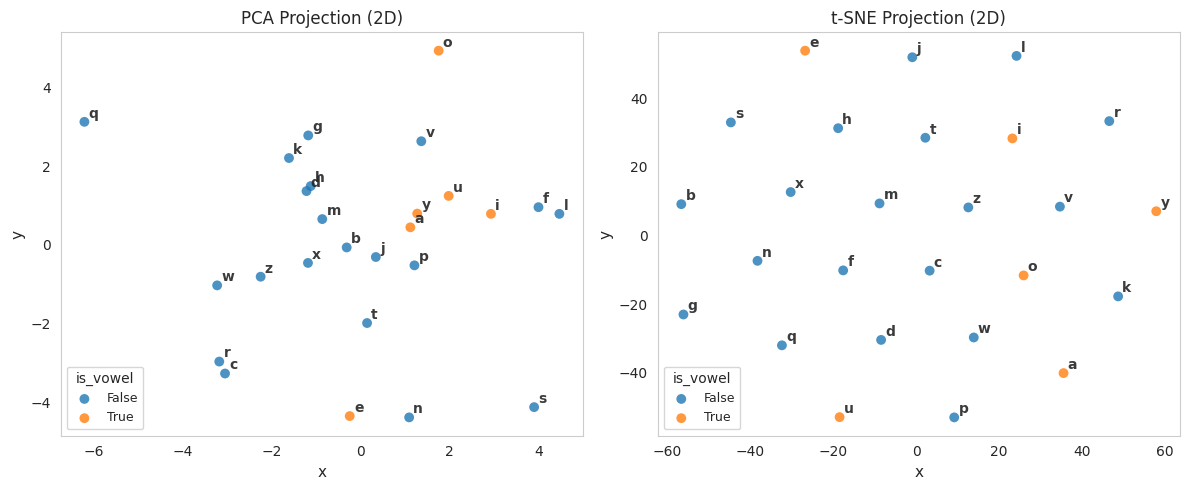

In [ ]:
# Цвета и маркеры как на вашем скриншоте
colors = {False: 'tab:blue', True: 'tab:orange'}
legend_labels = {False: 'False', True: 'True'}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# === PCA ===
ax = axes[0]
for is_vowel in [False, True]:
    mask = [t == ('vowel' if is_vowel else 'consonant') for t in letter_types]
    ax.scatter(embeddings_pca[mask, 0], embeddings_pca[mask, 1],
               c=colors[is_vowel], label=legend_labels[is_vowel],
               alpha=0.8, s=50, edgecolors='none')

    # Подписываем буквы
    for i, (x, y, name) in enumerate(zip(embeddings_pca[:, 0], embeddings_pca[:, 1], letter_names)):
        if letter_types[i] == ('vowel' if is_vowel else 'consonant'):
            ax.annotate(name, (x, y), fontsize=10, alpha=0.9,
                       xytext=(3, 3), textcoords='offset points', fontweight='bold')

ax.set_title("PCA Projection (2D)", fontsize=12)
ax.set_xlabel("x", fontsize=11)
ax.set_ylabel("y", fontsize=11)
ax.legend(title="is_vowel", loc="lower left", fontsize=9)
ax.grid(False)

# === t-SNE ===
ax = axes[1]
for is_vowel in [False, True]:
    mask = [t == ('vowel' if is_vowel else 'consonant') for t in letter_types]
    ax.scatter(embeddings_tsne[mask, 0], embeddings_tsne[mask, 1],
               c=colors[is_vowel], label=legend_labels[is_vowel],
               alpha=0.8, s=50, edgecolors='none')

    # Подписываем буквы
    for i, (x, y, name) in enumerate(zip(embeddings_tsne[:, 0], embeddings_tsne[:, 1], letter_names)):
        if letter_types[i] == ('vowel' if is_vowel else 'consonant'):
            ax.annotate(name, (x, y), fontsize=10, alpha=0.9,
                       xytext=(3, 3), textcoords='offset points', fontweight='bold')

ax.set_title("t-SNE Projection (2D)", fontsize=12)
ax.set_xlabel("x", fontsize=11)
ax.set_ylabel("y", fontsize=11)
ax.legend(title="is_vowel", loc="lower left", fontsize=9)
ax.grid(False)

plt.tight_layout()
plt.show()

In [ ]:
# Бинарная метка: гласная=1, согласная=0
binary_labels = [1 if t == 'vowel' else 0 for t in letter_types]

# Silhouette Score для PCA
sil_pca = silhouette_score(embeddings_pca, binary_labels)
print(f"\n Silhouette Score (PCA): {sil_pca:.3f}")

# Silhouette Score для t-SNE
sil_tsne = silhouette_score(embeddings_tsne, binary_labels)
print(f" Silhouette Score (t-SNE): {sil_tsne:.3f}")



 Silhouette Score (PCA): 0.051
 Silhouette Score (t-SNE): 0.052


# Сохранение результатов

In [ ]:
# 1. Сохраняем модель в формате pickle
MODEL_PATH = 'multi_task_model.pkl'
model_mtl.eval()  # Всегда сохраняем в режиме inference
with open(MODEL_PATH, 'wb') as f:
    pickle.dump(model_mtl, f)
print(f" Модель сохранена в {MODEL_PATH}")

# 2. Эмуляция загрузки коллегой (проверка целостности)
with open(MODEL_PATH, 'rb') as f:
    loaded_model = pickle.load(f)
loaded_model.eval()
loaded_model.to(device)

# 3. Прогнозирование на тестовом наборе
all_probs = []
all_labels = []

with torch.no_grad():
    for inputs, _, genders in test_loader:
        inputs = inputs.to(device)
        _, gender_probs = loaded_model(inputs)

        all_probs.extend(gender_probs.view(-1).cpu().numpy().tolist())
        all_labels.extend(genders.view(-1).numpy().tolist())

# 4. Расчёт метрики
auc_score = roc_auc_score(all_labels, all_probs)
print(f" Test ROC AUC: {auc_score:.4f}")



# 5. Сохранение прогнозов в CSV
predictions_df = pd.DataFrame({
    'name': final_test['name'].values,
    'true_gender': all_labels,
    'predicted_prob': all_probs
})
predictions_df.to_csv('test_predictions.csv', index=False)
print(" Предсказания сохранены в test_predictions.csv")

 Модель сохранена в multi_task_model.pkl
 Test ROC AUC: 0.9077
 Предсказания сохранены в test_predictions.csv
